# EEG Signals From Normal and MCI ( Mild Cognitive Impairment ) Cases

EEG Signals From Normal and MCI ( Mild Cognitive Impairment ) Cases: This dataset is a collection of scalp EEG from 27 subjects ( 16 normal and 11 MCI ) aged 60 to 77 with elementary or higher education and history of coronary angiography during recent year. They were selected from patients who admitted to cardiac catheterization units of Sina and Nour Hospitals, Isfahan, Iran. The study design was ethically discussed and approved by the deputy of research and technology, Isfahan University of Medical Sciences, Isfahan, Iran. Subjects with a history of major psychiatric disorders, substance misuse, head trauma, serious medical disease, and dementia were excluded.

The study process was explained for all subjects and written informed consent was obtained. Neuropsychiatric interview considering Peterson`s criteria for Mild Cognitive Impairment ( MCI ) has been done for all subjects. Mini-mental state examination ( MMSE ) scores from 21 to 26 were utilized for validation of MCI diagnosis and scores more than 26, were considered normal controls. Neuropsychiatry unit cognitive assessment tool ( NUCOG ) has been used to confirm the diagnosis of MCI and as a dependent variable.

All EEG signals were recorded in the morning times while subjects resting comfortably in a quiet room with closed eyes. The EEG activity was recorded continuously from 19 electrodes positioned according to the 10–20 International system using 32 channel digital EEG device with 256Hz sampling rate (Galileo NT, EBneuro, Italy). Electrodes-skin impedance was set below 5 kΩ. The recording duration was 30 minutes and during recording procedure subjects were been checked out continuously to keep them conscious and avoid drowsiness. All EEG signals were converted and saved in The European Data Format ( EDF ).

Please reference the following paper if you would like to use any part of this dataset :

M. Kashefpoor, H. Rabbani, and M. Barekatain, "Automatic Diagnosis of Mild Cognitive Impairment Using Electroencephalogram Spectral Features," J Med Signals Sens, vol. 6, pp. 25-32, Jan-Mar 2016

In [1]:
import os

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import mne # for read .edf file

Test

In [3]:
PATH = r"EEg_Data"
PATH_TEST = os.path.join(PATH, "1.edf")
df_1 = mne.io.read_raw_edf(PATH_TEST, preload=True)
print(df_1.info)

# Data channels
print("Channels:", df_1.ch_names)

# Full data
data = df_1.get_data()
print("Data shape:", data.shape)   # (n_channels, n_samples)

# Time
times = df_1.times
print("Time samples:", len(times))

# If has annotation 
print(df_1.annotations)

# Sample 0 to 10
print(data[0, :10])

Extracting EDF parameters from EEg_Data\1.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 465663  =      0.000 ...  1818.996 secs...
<Info | 8 non-empty values
 bads: []
 ch_names: Fp1, Fp2, F7, F3, Fz, F4, F8, T3, C3, Cz, C4, T4, T5, P3, Pz, ...
 chs: 19 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 128.0 Hz
 meas_date: 2080-01-01 00:00:00 UTC
 nchan: 19
 projs: []
 sfreq: 256.0 Hz
 subject_info: <subject_info | his_id: >
>
Channels: ['Fp1', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'T3', 'C3', 'Cz', 'C4', 'T4', 'T5', 'P3', 'Pz', 'P4', 'T6', 'O1', 'O2']
Data shape: (19, 465664)
Time samples: 465664
<Annotations | 0 segments>
[-8.5928893  -9.3494316  -8.35774777 -3.23575189 -4.86129549 -8.22484169
 -6.47661555 -7.85679408 -7.35584039 -2.48943313]


## Data recognition

In [5]:
# folder of file
PATH = r"EEg_Data"
list_of_file = os.listdir(PATH)
list_of_edf_file = [f for f in os.listdir(PATH) if f.endswith(".edf")]


In [17]:
file_name = "1"

file_name = file_name + ".edf"
for i in range(len(list_of_edf_file)):
    print(i)
    if list_of_edf_file[i] == file_name:
        inx_name = i
        break

PATH_FILE = os.path.join(PATH, file_name)
print(PATH_FILE)
df = mne.io.read_raw_edf(PATH_FILE, preload=True)
df

0
EEg_Data\1.edf
Extracting EDF parameters from EEg_Data\1.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 465663  =      0.000 ...  1818.996 secs...


<RawEDF | 1.edf, 19 x 465664 (1819.0 s), ~67.5 MiB, data loaded>

In [18]:
print("----------------")
print(df.info)
print("----------------")
print(f"Channels: {df.ch_names}")
print("----------------")
print(f"Duration: {df.times[-1]} seconds")

----------------
<Info | 8 non-empty values
 bads: []
 ch_names: Fp1, Fp2, F7, F3, Fz, F4, F8, T3, C3, Cz, C4, T4, T5, P3, Pz, ...
 chs: 19 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 128.0 Hz
 meas_date: 2080-01-01 00:00:00 UTC
 nchan: 19
 projs: []
 sfreq: 256.0 Hz
 subject_info: <subject_info | his_id: >
>
----------------
Channels: ['Fp1', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'T3', 'C3', 'Cz', 'C4', 'T4', 'T5', 'P3', 'Pz', 'P4', 'T6', 'O1', 'O2']
----------------
Duration: 1818.99609375 seconds


Using matplotlib as 2D backend.


<Figure size 1200x500 with 0 Axes>

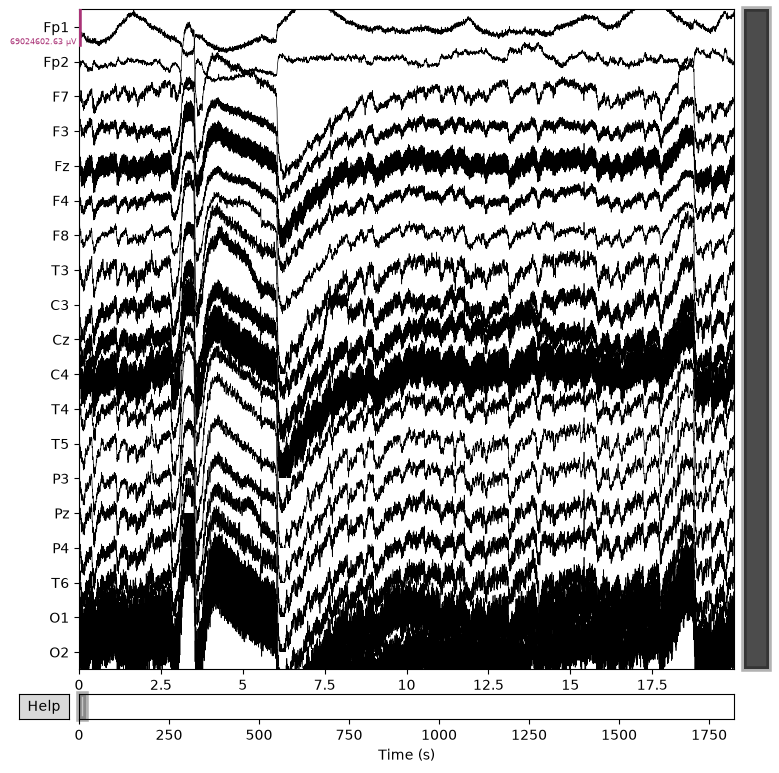

In [19]:
plt.figure(figsize=(12,5))
df.plot(duration=20, n_channels=19, scalings='auto', block=True)
plt.show()

One Channel `Fq1`

Signal shape: (465664,)
Sampling Rate (Sf): 256.0 Hz
First 10 samples: [-8.5928893  -9.3494316  -8.35774777 -3.23575189 -4.86129549 -8.22484169
 -6.47661555 -7.85679408 -7.35584039 -2.48943313]


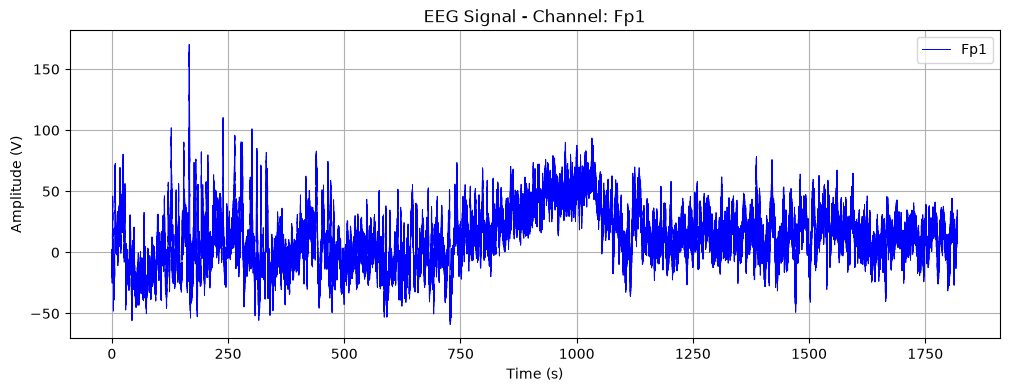

In [29]:
target_channel = 'Fp1'

# Data of channel
raw_channel = df.copy().pick([target_channel])
data, times = raw_channel.get_data(return_times=True)

signal = data[0]
print(f"Signal shape: {signal.shape}")
print(f"Sampling Rate (Sf): {df.info['sfreq']} Hz")
print(f"First 10 samples: {signal[:10]}")

plt.figure(figsize=(12, 4))
plt.plot(times, signal, label=target_channel, color='blue', lw=0.7)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude (V)')
plt.title(f'EEG Signal - Channel: {target_channel}')
plt.grid(True)
plt.legend()
plt.show()